In [49]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

rng = np.random.default_rng()

# 1. Метод обратной функции

Задана плотность $f(x) = \frac{e^x}{e - 1}$ при $x \in (0, 1)$ и $0$ иначе.

Из плотности $f(x)$ найдем распределение $F(x)$:  
$F(x) = \int_{-\infty}^{x} f(t)dt = \int_{-\infty}^{0} 0 dt + \int_{0}^{x} \frac{e^t}{e - 1}dt = \frac{1}{e - 1}(e^x - e^{0}) = \frac{e^x - 1}{e - 1}$ при $x \in (0, 1)$.

Найдем обратную функцию $G(y) = F^{-1}(y)$:  
$G(y) = \ln{1 + y(e - 1)}$ при $y \in (0, 1)$.

In [50]:
def G(y):
    return np.log(1 + y * (np.e - 1))

(а) Смоделируем $N = 10^8$ значений величины из распределения $F(x)$.

In [51]:
# а)
sample_size = 10 ** 8
sample = rng.uniform(0., 1., size=sample_size)
sample = G(sample)
num_bins = 32
sample_hist, bin_edges = np.histogram(sample, bins=num_bins, density=True)

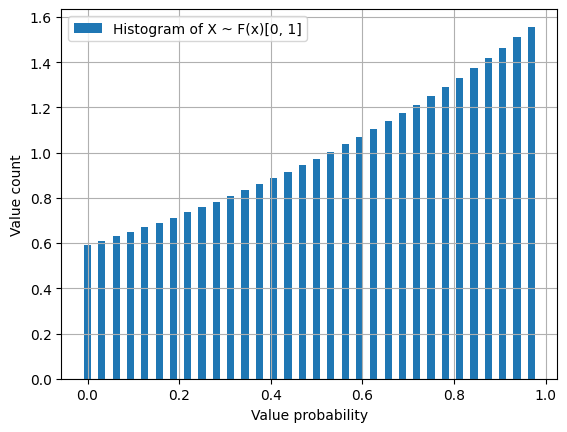

In [52]:
plt.bar(bin_edges[:-1], sample_hist, width=np.diff(bin_edges) / 2, label='Histogram of X ~ F(x)[0, 1]')
plt.xlabel('Value probability')
plt.ylabel('Value count')
plt.legend()
plt.grid()

(б) Найдем точные значения мат ожидания `mean_exact` и дисперсии `var_exact`.

$M_x = \int_{0}^{1} x f(x)dx = \int_{0}^{1} x \frac{e^x}{e - 1}dx = \frac{1}{e - 1}.$

$D_x = \int_{0}^{1} x^2 f(x)dx - M_x^2 =  \int_{0}^{1} x^2 \frac{e^x}{e - 1}dx - M_x^2 = \frac{e - 2}{e - 1} - (\frac{1}{e - 1})^2 = \frac{e^2 - 3e + 1}{(e - 1)^2}.$

In [53]:
# (б)
mean_exact = 1 / (np.e - 1)
var_exact = (np.e ** 2 - 3 * np.e + 1) / (np.e - 1) ** 2

mean_exact, var_exact

(0.5819767068693265, 0.07932640579220746)

(в) Вычислим оценки мат ожидания и сравним их с точными значениями.

In [54]:
# (в)
sample_sizes = [10 ** n for n in range(2, 9)]
sample_means = []
sample_vars = []

progress_bar = tqdm(sample_sizes, desc=f"Compute mean and var for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = rng.uniform(0., 1., size=sample_size)
    sample = G(sample)
    sample_mean = np.mean(sample)
    sample_var = np.var(sample)

    sample_means.append(sample_mean)
    sample_vars.append(sample_var)

Compute mean and var for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]:   0%|          | 0/7 [00:00<?, ?it/s]

Compute mean and var for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:03<00:00,  2.01it/s]


Вычислим оценки мат ожидания для различных размеров выборки $N$, и сравным с точным значением `mean_exact` на графике.

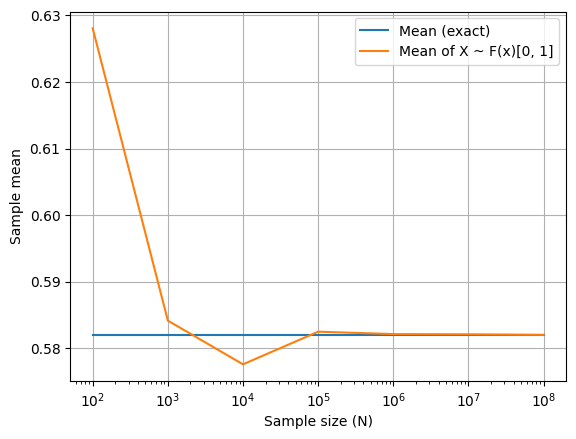

In [55]:
plt.plot(sample_sizes, [mean_exact] * len(sample_sizes), label='Mean (exact)')
plt.plot(sample_sizes, sample_means, label='Mean of X ~ F(x)[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample mean')
plt.xscale('log')
plt.legend()
plt.grid()

Вычислим оценки дисперсии для различных размеров выборки $N$, и сравным с точным значением `var_exact` на графике.

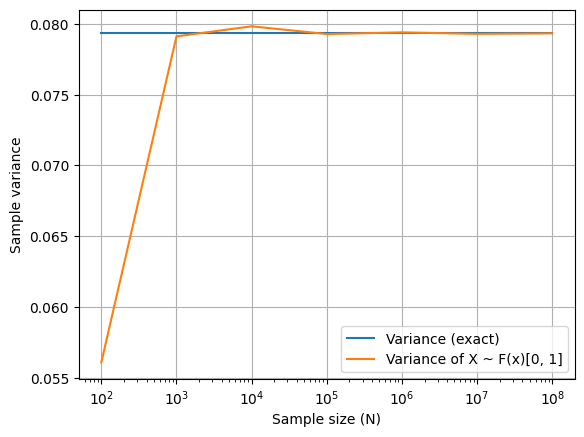

In [56]:
plt.plot(sample_sizes, [var_exact] * len(sample_sizes), label='Variance (exact)')
plt.plot(sample_sizes, sample_vars, label='Variance of X ~ F(x)[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample variance')
plt.xscale('log')
plt.legend()
plt.grid()

**Итог**: при размере выборки $N \geq 10^5$ оценки мат ожидания и дисперсии слабо отличаются от точных значений.

# 2. Метод Монте-Карло

Задана функция $f(x) = \sqrt{x} + 1$, $x \in (1, 4)$.

Найдем точное значение интеграла:  
$I = \int_{1}^{4} f(x)dx = \int_{1}^{4} (\sqrt{x} + 1)dx = \frac{23}{3} \approx 7.67$.

In [57]:
integral_exact = 23 / 3

Найдем приближенное `integral_est` значение интеграла методом Монте-Карло и сравним его с точным `integral_exact`:

In [58]:
def f(x):
    return np.sqrt(x) + 1

x_min, x_max = 1, 4
y_min, y_max = 0, f(x_max)

In [59]:
sample_sizes = [10 ** n for n in range(2, 9)]
integral_estimates = []

progress_bar = tqdm(sample_sizes, desc=f"Compute integral estimates sample sizes {sample_sizes}")
for sample_size in progress_bar:
    x_values = rng.uniform(x_min, x_max, size=sample_size)
    y_values = rng.uniform(y_min, y_max, size=sample_size)
    f_values = f(x_values)

    points_inside = np.sum(y_values < f_values)
    prob_est = points_inside / sample_size

    integral_est = prob_est * y_max * (x_max - x_min)
    integral_estimates.append(integral_est)

Compute integral estimates sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:09<00:00,  1.42s/it]


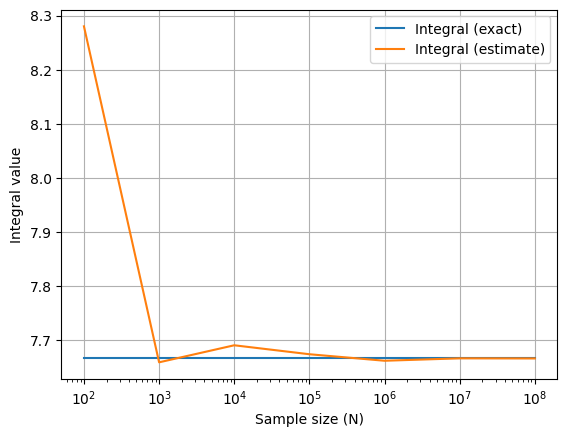

In [60]:
plt.plot(sample_sizes, [integral_exact] * len(sample_sizes), label='Integral (exact)')
plt.plot(sample_sizes, integral_estimates, label='Integral (estimate)')
plt.xlabel('Sample size (N)')
plt.ylabel('Integral value')
plt.xscale('log')
plt.legend()
plt.grid()

Визуализируем метод Монте-Карло для функции $f(x)$ на примере $N = 1000$ случайных точек.

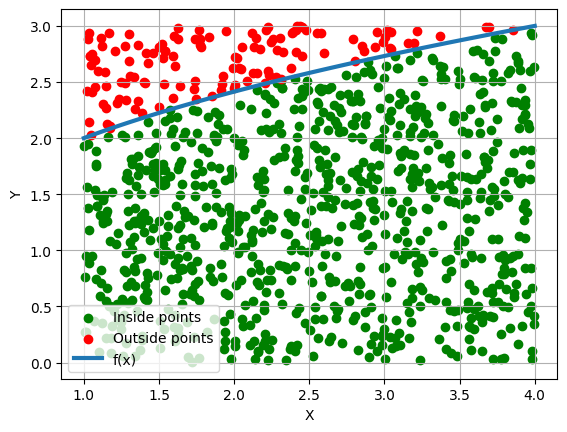

In [70]:
sample_size = 1000

x_axis = np.linspace(x_min, x_max, num=100)

x_values = rng.uniform(x_min, x_max, size=sample_size)
y_values = rng.uniform(y_min, y_max, size=sample_size)

under = y_values < f(x_values)
plt.scatter(x_values[under], y_values[under], c='green', label='Inside points')
plt.scatter(x_values[~under], y_values[~under], c='red', label='Outside points')

plt.plot(x_axis, f(x_axis), label='f(x)', linewidth=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()

**Итог**: при количестве точек $N \geq 10^7$ оценка интеграла слабо отличается от точного значения.